# **Licenciatura em Ciências da Computação**

### Aprendizagem Computacional 25/26

# IMDB Sentiment Analysis: Feature Engineering Challenge

## 1. Setup & Data Loading

First, we'll grab the dataset. We'll use a subset (10,000 rows) to keep the processing fast during class.

In [29]:
import pandas as pd
import numpy as np
import string
import re
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, f1_score
from sklearn.feature_extraction.text import CountVectorizer

# Load dataset (directly from a common source)
df = pd.read_csv('IMDB-Dataset.csv').sample(10000, random_state=42) # Subset for speed

# Encode target
df['label'] = df['sentiment'].map({'positive': 1, 'negative': 0})
df = df.drop(['sentiment'],axis=1)

print(f"Dataset loaded with {df.shape[0]} reviews.")
df.head()

Dataset loaded with 10000 reviews.


,review,label
33553,I really liked this Summerslam due to the look...,1
9427,Not many television shows appeal to quite as m...,1
199,The film quickly gets to a major chase scene w...,0
12447,Jane Austen would definitely approve of this o...,1
39489,Expectations were somewhat high for me when I ...,0


In [30]:
df['label'].value_counts()

label
1    5039
0    4961
Name: count, dtype: int64

## 2. The "Baseline" Model
To know if our features are actually good, we need a baseline. This uses a simple Bag of Words (BoW) approach.

In [31]:
# Simple vectorization
def simple_clean(text):
    # Convert to lowercase
    text = text.lower()
    # Standardize whitespace (replace multiple whitespaces with a single space)
    text = re.sub(r'\s+', ' ', text).strip()
    # remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    # remove digits
    text = re.sub(r'\d+', '', text)
    return text

# Aplicar a limpeza
df['review_cleaned'] = df['review'].apply(simple_clean)

vectorizer = CountVectorizer(max_features=10000)
X_baseline = vectorizer.fit_transform(df['review_cleaned'])
y = df['label']

# Split
X_train, X_test, y_train, y_test = train_test_split(X_baseline, y, test_size=0.2, random_state=42)

# Train a simple Logistic Regression
baseline_model = LogisticRegression(max_iter=1000)
baseline_model.fit(X_train, y_train)

# Evaluate
preds = baseline_model.predict(X_test)
print(f"Baseline F1-Score: {f1_score(y_test, preds):.4f}")

Baseline F1-Score: 0.8580


## 3. The Challenge: Feature Engineering Sandbox
Your goal is to create a function that extracts new numerical features from the raw text. Think about:

Metadata: Length, punctuation, capitalization.

Lexicons: Positive/Negative word counts.

Context: Handling "not" or "never."

In [32]:
def extract_custom_features(text):
    """
    Students: Edit this function to create your features!
    Return a list or numpy array of numbers.
    """
    features = []

    # Example Feature 1: Word Count
    words = text.split()
    features.append(len(words))

    # Example Feature 2: Count of Exclamation Marks
    features.append(text.count('!'))

    # Example Feature 3: 'No/Not' density (Simple Negation)
    negations = len(re.findall(r'\b(not|no|never|neither|nor)\b', text.lower()))
    features.append(negations)

    # --- ADD YOUR OWN IDEAS BELOW ---
    maiusculas = len(re.findall(r'[A-Z]',text))
    features.append(maiusculas)

    return features

# Apply your features to the dataframe
custom_features_list = df['review'].apply(extract_custom_features).tolist()
X_custom = np.array(custom_features_list)

print(f"New feature matrix shape: {X_custom.shape}")
features_df = pd.DataFrame(X_custom, columns=['word_count', 'exclamations', 'negations', 'maiusculas'])
features_df.head()

New feature matrix shape: (10000, 4)


,word_count,exclamations,negations,maiusculas
0,201,0,0,58
1,354,3,1,42
2,119,0,1,10
3,99,3,2,28
4,332,0,3,77


Additional Tips:

- Check Stop words
- TF-IDF

## 4. Combine All Features
Combinar as features manuais (custom) com as features Bag-of-Words numa única matriz.

In [33]:
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, ConfusionMatrixDisplay
from scipy.stats import ttest_rel
import matplotlib.pyplot as plt

# Converter BoW sparse matrix para DataFrame
X_baseline_df = pd.DataFrame(
    X_baseline.toarray(),
    columns=vectorizer.get_feature_names_out(),
    index=df.index
)

# Alinhar o index do features_df com o df
features_df.index = df.index

# Combinar features manuais + BoW
X_combined = pd.concat([features_df, X_baseline_df], axis=1)

print(f"Shape de X_combined: {X_combined.shape}")
print(f"  - Features manuais: {features_df.shape[1]}")
print(f"  - Features BoW: {X_baseline_df.shape[1]}")
X_combined.head()

Shape de X_combined: (10000, 10004)
  - Features manuais: 4
  - Features BoW: 10000


,word_count,exclamations,negations,maiusculas,aamir,aaron,abandon,abandoned,abbey,abbott,...,zany,zealand,zero,zoey,zombie,zombies,zone,zoo,zoom,zucco
33553,201,0,0,58,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9427,354,3,1,42,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
199,119,0,1,10,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12447,99,3,2,28,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
39489,332,0,3,77,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## 5. Train/Test Split (Combined Features)
Re-split usando a matriz combinada para que todas as features sejam usadas no treino e avaliação.

In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    X_combined, y, test_size=0.2, random_state=42
)

print(f"Train size: {X_train.shape}")
print(f"Test size:  {X_test.shape}")

Train size: (8000, 10004)
Test size:  (2000, 10004)


## 6. Feature Selection
Usar `SelectKBest` com `chi2` para selecionar ~75% das features mais relevantes.

In [35]:
k_features = int(0.75 * X_train.shape[1])

selector = SelectKBest(chi2, k=k_features)
selector.fit(X_train, y_train)

X_train_selected = selector.transform(X_train)

selected_features = X_train.columns[selector.get_support(indices=True)]
X_train_selected = pd.DataFrame(
    X_train_selected,
    columns=selected_features,
    index=X_train.index
)

print(f"Features originais: {X_train.shape[1]}")
print(f"Features selecionadas (k): {k_features}")
print(f"Shape de X_train_selected: {X_train_selected.shape}")
X_train_selected.head()

Features originais: 10004
Features selecionadas (k): 7503
Shape de X_train_selected: (8000, 7503)


,word_count,exclamations,negations,maiusculas,aamir,aaron,abandon,abandoned,abbey,abc,...,youtube,youve,yrs,zany,zero,zoey,zombie,zombies,zoo,zucco
2141,153,1,6,23,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
46172,114,0,1,16,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
18558,232,2,6,50,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
32956,260,0,0,30,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
13094,470,0,2,111,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## 7. Cross-Validation
Configurar Stratified K-Fold e avaliar dois modelos: **Multinomial Naive Bayes** e **KNN**.

In [36]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Reset index para garantir slicing correto
X_train_selected_reset = X_train_selected.reset_index(drop=True)
y_train_reset = y_train.reset_index(drop=True)

# --- Multinomial Naive Bayes ---
mnb_f1_scores = []
mnb = MultinomialNB()

for train_index, val_index in skf.split(X_train_selected_reset, y_train_reset):
    X_train_fold = X_train_selected_reset.iloc[train_index]
    X_val_fold = X_train_selected_reset.iloc[val_index]
    y_train_fold = y_train_reset.iloc[train_index]
    y_val_fold = y_train_reset.iloc[val_index]

    mnb.fit(X_train_fold, y_train_fold)
    y_pred = mnb.predict(X_val_fold)
    mnb_f1_scores.append(f1_score(y_val_fold, y_pred))

print(f"MultinomialNB CV F1-score Mean: {np.mean(mnb_f1_scores):.4f}")
print(f"MultinomialNB CV F1-score Std:  {np.std(mnb_f1_scores):.4f}")

MultinomialNB CV F1-score Mean: 0.8327
MultinomialNB CV F1-score Std:  0.0157


In [37]:
# --- K-Nearest Neighbors ---
knn_f1_scores = []
knn = KNeighborsClassifier(n_neighbors=5)

for train_index, val_index in skf.split(X_train_selected_reset, y_train_reset):
    X_train_fold = X_train_selected_reset.iloc[train_index]
    X_val_fold = X_train_selected_reset.iloc[val_index]
    y_train_fold = y_train_reset.iloc[train_index]
    y_val_fold = y_train_reset.iloc[val_index]

    knn.fit(X_train_fold, y_train_fold)
    y_pred = knn.predict(X_val_fold)
    knn_f1_scores.append(f1_score(y_val_fold, y_pred))

print(f"KNN CV F1-score Mean: {np.mean(knn_f1_scores):.4f}")
print(f"KNN CV F1-score Std:  {np.std(knn_f1_scores):.4f}")

KNN CV F1-score Mean: 0.5474
KNN CV F1-score Std:  0.0048


## 8. Compare Models + Paired T-test
Comparar os resultados de cross-validation e verificar se a diferença é estatisticamente significativa.

In [38]:
print("=== Comparação de Modelos ===\n")
print(f"MultinomialNB  F1 Mean: {np.mean(mnb_f1_scores):.4f} ± {np.std(mnb_f1_scores):.4f}")
print(f"KNN            F1 Mean: {np.mean(knn_f1_scores):.4f} ± {np.std(knn_f1_scores):.4f}")

print("\nScores por fold:")
print("MNB:", [f"{s:.4f}" for s in mnb_f1_scores])
print("KNN:", [f"{s:.4f}" for s in knn_f1_scores])

# Paired t-test
t_statistic, p_value = ttest_rel(mnb_f1_scores, knn_f1_scores)
print(f"\nPaired t-test p-value: {p_value:.4f}")
if p_value < 0.05:
    print("=> Diferença estatisticamente significativa (p < 0.05)")
else:
    print("=> Diferença NÃO é estatisticamente significativa (p >= 0.05)")

=== Comparação de Modelos ===

MultinomialNB  F1 Mean: 0.8327 ± 0.0157
KNN            F1 Mean: 0.5474 ± 0.0048

Scores por fold:
MNB: ['0.8595', '0.8361', '0.8340', '0.8162', '0.8175']
KNN: ['0.5411', '0.5435', '0.5474', '0.5506', '0.5543']

Paired t-test p-value: 0.0000
=> Diferença estatisticamente significativa (p < 0.05)


## 9. Train Final Model
Treinar o melhor modelo (baseado nos resultados do CV) com todos os dados de treino.

In [39]:
# Escolher o melhor modelo baseado no CV
if np.mean(mnb_f1_scores) >= np.mean(knn_f1_scores):
    print("Melhor modelo: MultinomialNB")
    final_model = MultinomialNB()
else:
    print("Melhor modelo: KNN")
    final_model = KNeighborsClassifier(n_neighbors=5)

final_model.fit(X_train_selected, y_train)
print("Modelo final treinado com sucesso!")

Melhor modelo: MultinomialNB
Modelo final treinado com sucesso!


## 10. Evaluate on Test Set
Preparar os dados de teste com as mesmas transformações e avaliar o modelo final.

In [40]:
# Aplicar Feature Selection ao test set (usando o selector já fitted)
X_test_selected = selector.transform(X_test)
X_test_selected = pd.DataFrame(
    X_test_selected,
    columns=selected_features,
    index=X_test.index
)

# Prever
y_pred_test = final_model.predict(X_test_selected)

# Métricas
print("=== Avaliação no Test Set ===\n")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_test):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_test):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_test):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_test):.4f}")
print(f"\n{classification_report(y_test, y_pred_test)}")

=== Avaliação no Test Set ===

Accuracy:  0.8285
Precision: 0.8507
Recall:    0.7972
F1-Score:  0.8231

              precision    recall  f1-score   support

           0       0.81      0.86      0.83       999
           1       0.85      0.80      0.82      1001

    accuracy                           0.83      2000
   macro avg       0.83      0.83      0.83      2000
weighted avg       0.83      0.83      0.83      2000



<Figure size 600x500 with 0 Axes>

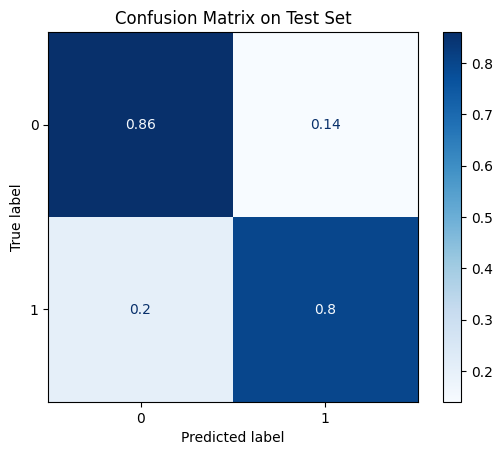

In [41]:
# Confusion Matrix
plt.figure(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_test, cmap='Blues', normalize='true')
plt.title('Confusion Matrix on Test Set')
plt.grid(False)
plt.show()